# Left/Right Sign Detection with YOLO11

로버 차량 카메라 프레임으로 `left`, `right` 표지판을 학습하는 노트북입니다.

이번 버전은 `Roboflow에서 라벨링과 train/val/test split을 수행`하는 흐름으로 정리했습니다.


## 0) 환경 설정

- 작업 루트: `/home/jungjinwoo/Embe_learning`
- 추출 프레임: `extracted_frames/`
- Roboflow 업로드용 이미지: `roboflow_upload/`
- Roboflow export zip 또는 압축 해제본: `roboflow_export/`


In [1]:
# 필요 시 주석 해제 후 실행
# %pip install -q ultralytics opencv-python matplotlib pyyaml


In [2]:
from pathlib import Path
import math
import random
import shutil
import zipfile
import yaml
import cv2
import matplotlib.pyplot as plt

from yolo_left_right.notebook_utils import (
    VALID_EXTS,
    draw_yolo_boxes,
    image_dir_to_label_dir,
    prepare_local_dataset,
    resolve_run_dir,
)

try:
    import torch
except Exception:
    torch = None

try:
    from ultralytics import YOLO
except Exception:
    YOLO = None


## 1) 프로젝트 경로 설정


In [3]:
PROJECT_ROOT = Path('/home/jungjinwoo/Embe_learning')
FRAMES_ROOT = PROJECT_ROOT / 'extracted_frames'
WORK_ROOT = PROJECT_ROOT / 'yolo_left_right'
UPLOAD_ROOT = WORK_ROOT / 'roboflow_upload'
EXPORT_ROOT = WORK_ROOT / 'roboflow_export'
RUNS_ROOT = WORK_ROOT / 'runs'
DATASET_ROOT = WORK_ROOT / 'dataset'
DATA_YAML_PATH = WORK_ROOT / 'left_right_signs.yaml'

for path in [WORK_ROOT, UPLOAD_ROOT, EXPORT_ROOT, RUNS_ROOT, DATASET_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('FRAMES_ROOT  :', FRAMES_ROOT)
print('UPLOAD_ROOT  :', UPLOAD_ROOT)
print('EXPORT_ROOT  :', EXPORT_ROOT)
print('RUNS_ROOT    :', RUNS_ROOT)
print('DATASET_ROOT :', DATASET_ROOT)
print('DATA_YAML    :', DATA_YAML_PATH)


PROJECT_ROOT: /home/jungjinwoo/Embe_learning
FRAMES_ROOT  : /home/jungjinwoo/Embe_learning/extracted_frames
UPLOAD_ROOT  : /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_upload
EXPORT_ROOT  : /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_export
RUNS_ROOT    : /home/jungjinwoo/Embe_learning/yolo_left_right/runs
DATASET_ROOT : /home/jungjinwoo/Embe_learning/yolo_left_right/dataset
DATA_YAML    : /home/jungjinwoo/Embe_learning/yolo_left_right/left_right_signs.yaml


## 2) 추출된 프레임 확인


In [4]:
valid_exts = VALID_EXTS

left_frames = sorted([
    path for path in (FRAMES_ROOT / 'left').rglob('*')
    if path.is_file() and path.suffix.lower() in valid_exts
])
right_frames = sorted([
    path for path in (FRAMES_ROOT / 'right').rglob('*')
    if path.is_file() and path.suffix.lower() in valid_exts
])

print('left frames :', len(left_frames))
print('right frames:', len(right_frames))
print('total       :', len(left_frames) + len(right_frames))


left frames : 119
right frames: 116
total       : 235


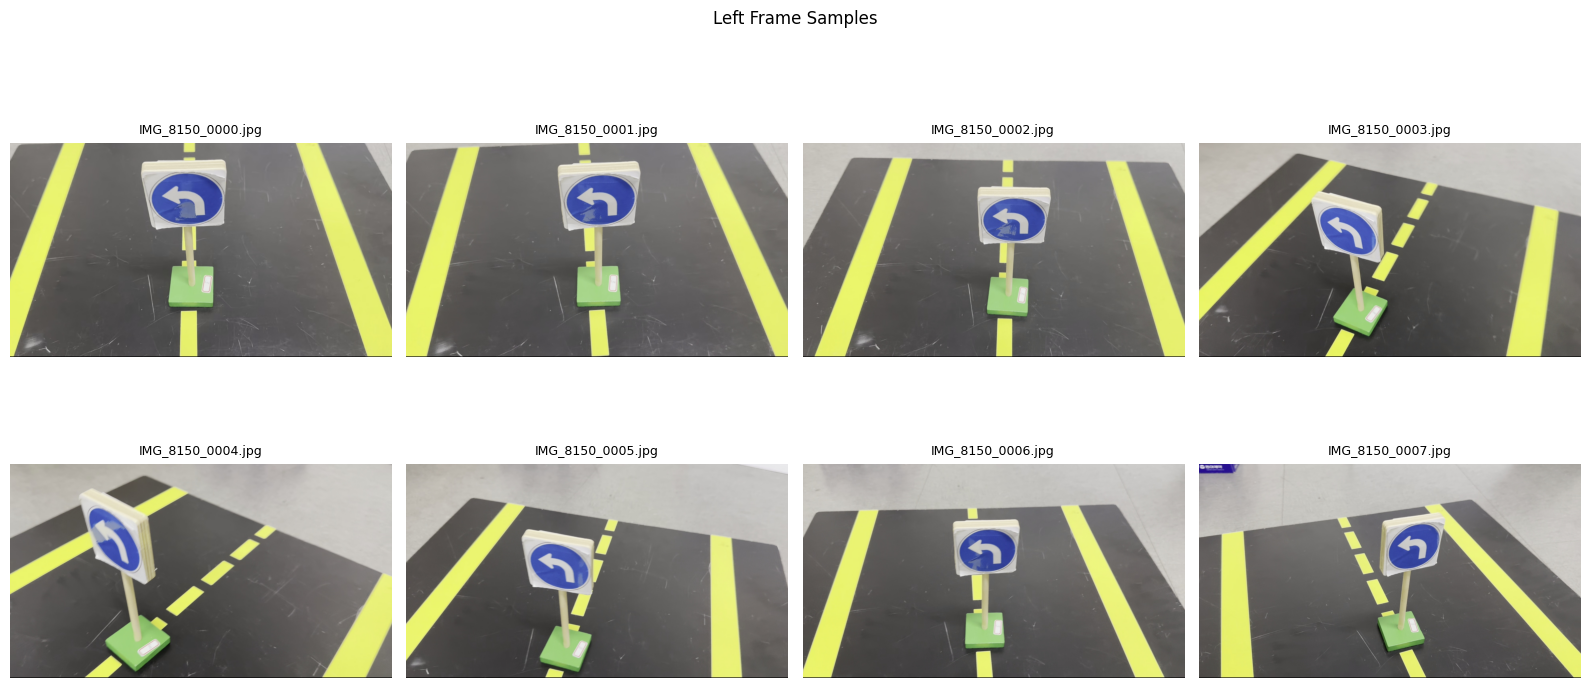

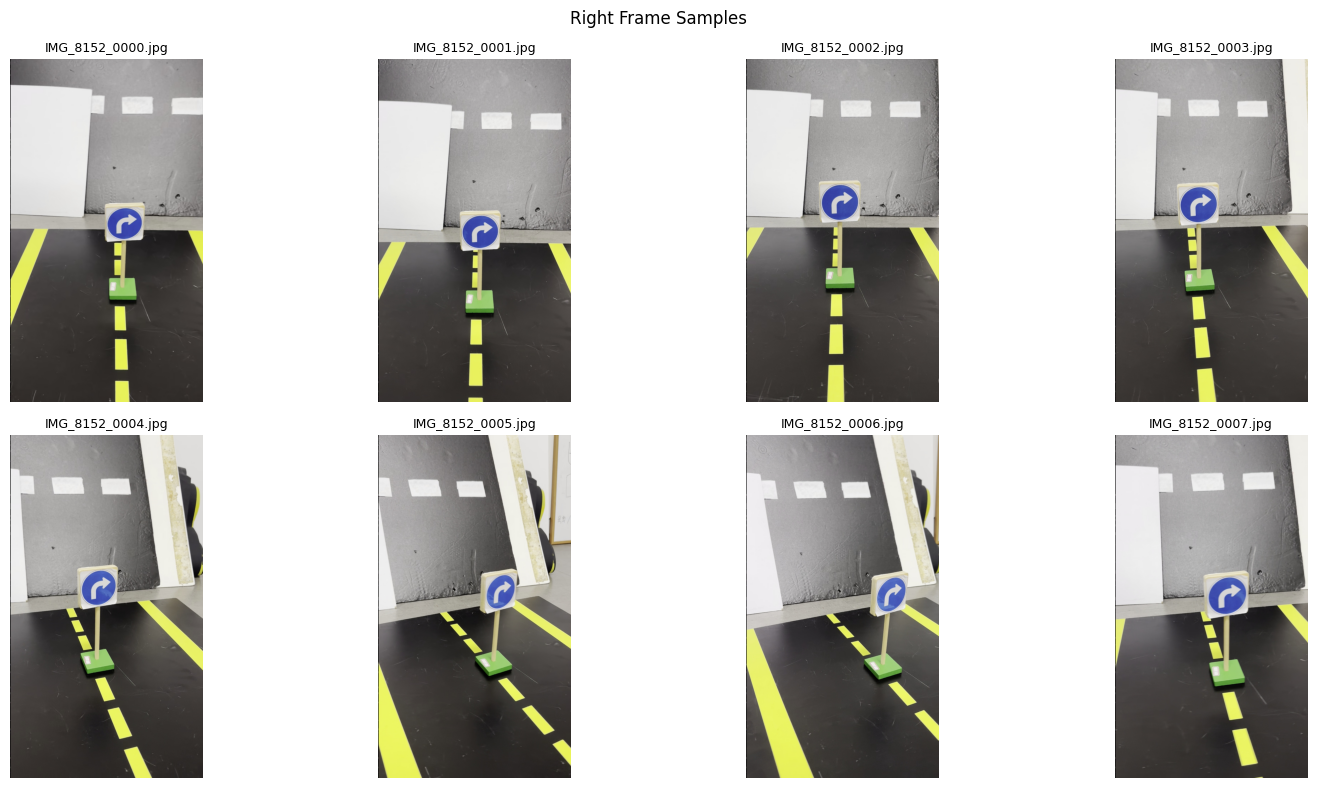

In [5]:
def show_images(image_paths, title, cols=4, max_images=8):
    sample_paths = image_paths[:max_images]
    if not sample_paths:
        print(f'No images for {title}')
        return
    rows = math.ceil(len(sample_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax in axes:
        ax.axis('off')
    for ax, image_path in zip(axes, sample_paths):
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.set_title(image_path.name, fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(left_frames, 'Left Frame Samples')
show_images(right_frames, 'Right Frame Samples')


## 3) Roboflow 업로드용 이미지 준비

이번 테스트는 `left 30장`, `right 30장` 정도의 소형셋을 목표로 합니다.

- 먼저 간격을 두고 후보를 줄입니다.
- 그 다음 각 클래스에서 최대 30장까지만 업로드합니다.
- 업로드 파일명 앞에 `left__`, `right__`를 붙여 클래스 출처를 구분합니다.


In [6]:
LEFT_STEP = 3
RIGHT_STEP = 3
MAX_LEFT_UPLOAD = 30
MAX_RIGHT_UPLOAD = 30
CLEAR_OLD_UPLOAD_IMAGES = True

if CLEAR_OLD_UPLOAD_IMAGES:
    for old_file in UPLOAD_ROOT.glob('*'):
        if old_file.is_file():
            old_file.unlink()

selected_left = left_frames[::LEFT_STEP][:MAX_LEFT_UPLOAD]
selected_right = right_frames[::RIGHT_STEP][:MAX_RIGHT_UPLOAD]

for src_path in selected_left:
    dst_name = f'left__{src_path.stem}{src_path.suffix.lower()}'
    shutil.copy2(src_path, UPLOAD_ROOT / dst_name)

for src_path in selected_right:
    dst_name = f'right__{src_path.stem}{src_path.suffix.lower()}'
    shutil.copy2(src_path, UPLOAD_ROOT / dst_name)

print('selected left :', len(selected_left))
print('selected right:', len(selected_right))
print('upload images :', len(list(UPLOAD_ROOT.glob('*'))))
print('upload folder :', UPLOAD_ROOT)


selected left : 30
selected right: 30
upload images : 60
upload folder : /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_upload


## 4) Roboflow 작업

이 단계는 브라우저에서 수행합니다.

1. `UPLOAD_ROOT`의 이미지를 Roboflow 프로젝트에 업로드
2. 클래스 2개 생성: `left`, `right`
3. 박스 라벨링 진행
4. Roboflow에서 `train / val / test` split 수행
5. `YOLOv8` 형식으로 export
6. export zip 또는 압축 해제본을 `EXPORT_ROOT`에 저장

주의:
- Roboflow에서 split까지 끝내면 이 노트북에서는 별도 분할을 하지 않습니다.
- export 후 `data.yaml`, `train/`, `valid/`, `test/` 또는 유사 구조가 있어야 합니다.
- 이 정도 소형셋이면 split은 Roboflow에서 하는 편이 낫습니다. 추천 비율은 `70 / 20 / 10`입니다.


In [7]:
print('Upload this folder to Roboflow:')
print(UPLOAD_ROOT)
print('\nPut Roboflow export zip or extracted dataset here:')
print(EXPORT_ROOT)


Upload this folder to Roboflow:
/home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_upload

Put Roboflow export zip or extracted dataset here:
/home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_export


## 5) Roboflow export 압축 해제

Roboflow에서 받은 zip 파일을 `EXPORT_ROOT`에 넣었다면 아래 셀로 압축을 풉니다.
이미 압축을 풀어둔 상태면 이 셀은 건너뛰면 됩니다.


In [8]:
zip_files = sorted(EXPORT_ROOT.glob('*.zip'))
print('zip files:', [path.name for path in zip_files])

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(EXPORT_ROOT)
    print('extracted:', zip_path.name)


zip files: []


## 6) Roboflow export 구조 확인

`data.yaml` 위치를 찾고, 학습에 필요한 경로가 있는지 확인합니다.


In [9]:
yaml_candidates = sorted(EXPORT_ROOT.rglob('data.yaml'))
print('data.yaml candidates:')
for path in yaml_candidates:
    print('-', path)

if not yaml_candidates:
    raise FileNotFoundError('No data.yaml found under roboflow_export')

print('\nFound source data.yaml:', yaml_candidates[0])
print(yaml_candidates[0].read_text(encoding='utf-8'))


data.yaml candidates:
- /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_export/data.yaml

Found source data.yaml: /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_export/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['left', 'right']

roboflow:
  workspace: s-workspace-l3bh5
  project: s-workspace-l3bh5
  version: dataset
  license: Private
  url: https://app.roboflow.com/s-workspace-l3bh5/s-workspace-l3bh5/dataset


## 7) 라벨링 결과 샘플 미리보기

Roboflow export의 라벨을 읽어와 박스를 그려봅니다.


In [10]:
dataset_info = prepare_local_dataset(
    export_root=EXPORT_ROOT,
    dataset_root=DATASET_ROOT,
    data_yaml_out=DATA_YAML_PATH,
    seed=42,
)

DATA_YAML_PATH = dataset_info['data_yaml_path']
train_img_dir = dataset_info['train_img_dir']
val_img_dir = dataset_info['val_img_dir']
test_img_dir = dataset_info['test_img_dir']
id_to_name = dataset_info['id_to_name']

print('source_yaml_path :', dataset_info['source_yaml_path'])
print('prepared_yaml    :', DATA_YAML_PATH)
print('train_img_dir    :', train_img_dir)
print('val_img_dir      :', val_img_dir)
print('test_img_dir     :', test_img_dir)
print('used_auto_split  :', dataset_info['used_auto_split'])
print('split_counts     :', dataset_info['split_counts'])
print('\nPrepared YAML contents:')
print(DATA_YAML_PATH.read_text(encoding='utf-8'))


source_yaml_path : /home/jungjinwoo/Embe_learning/yolo_left_right/roboflow_export/data.yaml
prepared_yaml    : /home/jungjinwoo/Embe_learning/yolo_left_right/left_right_signs.yaml
train_img_dir    : /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/images/train
val_img_dir      : /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/images/val
test_img_dir     : /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/images/test
used_auto_split  : True
split_counts     : {'train': 49, 'val': 6, 'test': 6}

Prepared YAML contents:
path: /home/jungjinwoo/Embe_learning/yolo_left_right/dataset
train: images/train
val: images/val
test: images/test
names:
  0: left
  1: right



preview_dir: /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/images/train
label_dir  : /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/labels/train
num_images : 6


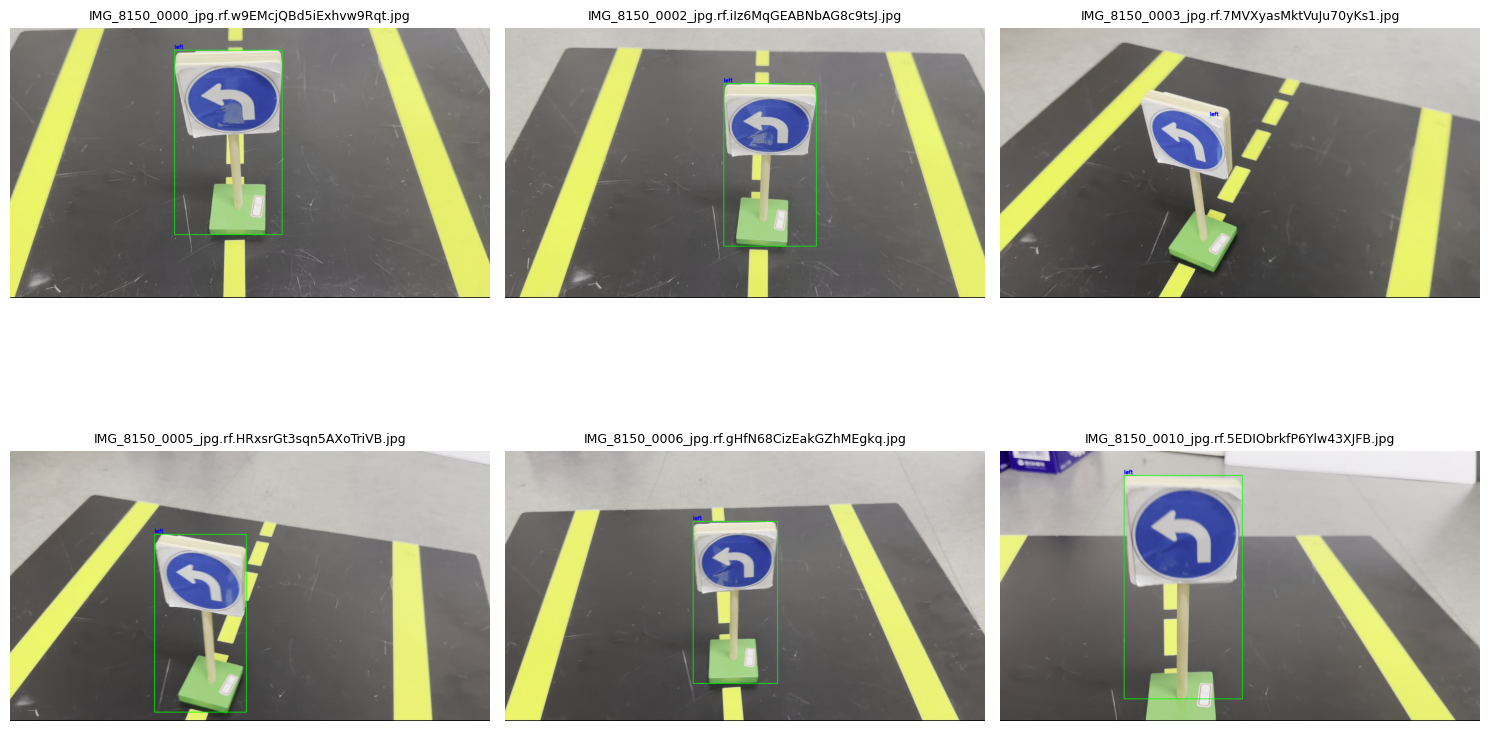

In [11]:
preview_dir = train_img_dir if train_img_dir.exists() else val_img_dir
preview_images = sorted([
    path for path in preview_dir.rglob('*')
    if path.is_file() and path.suffix.lower() in valid_exts
])
preview_images = preview_images[:min(6, len(preview_images))]

if not preview_images:
    print('No preview images found.')
else:
    label_dir = image_dir_to_label_dir(preview_dir)
    print('preview_dir:', preview_dir)
    print('label_dir  :', label_dir)
    print('num_images :', len(preview_images))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for ax in axes:
        ax.axis('off')
    for ax, image_path in zip(axes, preview_images):
        label_path = label_dir / f'{image_path.stem}.txt'
        if not label_path.exists():
            print('Missing label:', label_path)
        ax.imshow(draw_yolo_boxes(image_path, label_path, id_to_name))
        ax.set_title(image_path.name, fontsize=9)
    plt.tight_layout()
    plt.show()


## 8) YOLO11 학습

- Roboflow export는 `YOLOv8` 형식이어도 Ultralytics에서 그대로 학습할 수 있습니다.
- 기존 프로젝트에 맞춰 기본 베이스 모델은 `yolo11n.pt`로 둡니다.
- 데이터가 적으므로 augmentation을 같이 켭니다.


In [12]:
MODEL_NAME = 'yolo11n.pt'
EPOCHS = 50
IMGSZ = 640
DEVICE = 0 if torch is not None and torch.cuda.is_available() else 'cpu'
RUN_NAME = 'left_right_sign_yolo11n'

# Small dataset augmentation settings
AUGMENT = True
HSV_H = 0.015
HSV_S = 0.5
HSV_V = 0.3
DEGREES = 10.0
TRANSLATE = 0.08
SCALE = 0.2
SHEAR = 0.0
PERSPECTIVE = 0.0
FLIPUD = 0.0
FLIPLR = 0.5
MOSAIC = 0.3
MIXUP = 0.0
COPY_PASTE = 0.0

if YOLO is None:
    raise ImportError('ultralytics is not installed. Install it first.')

print('training device:', DEVICE)
if DEVICE != 'cpu' and torch is not None:
    print('cuda device    :', torch.cuda.get_device_name(DEVICE))

train_model = YOLO(MODEL_NAME)
train_results = train_model.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    device=DEVICE,
    project=str(RUNS_ROOT),
    name=RUN_NAME,
    augment=AUGMENT,
    hsv_h=HSV_H,
    hsv_s=HSV_S,
    hsv_v=HSV_V,
    degrees=DEGREES,
    translate=TRANSLATE,
    scale=SCALE,
    shear=SHEAR,
    perspective=PERSPECTIVE,
    flipud=FLIPUD,
    fliplr=FLIPLR,
    mosaic=MOSAIC,
    mixup=MIXUP,
    copy_paste=COPY_PASTE,
)

print('train save_dir:', getattr(train_results, 'save_dir', 'unknown'))


training device: 0
cuda device    : NVIDIA GeForce RTX 3050
Ultralytics 8.4.48 🚀 Python-3.8.20 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050, 7831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jungjinwoo/Embe_learning/yolo_left_right/left_right_signs.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0,

## 9) 검증 및 테스트 추론


In [13]:
run_dir = resolve_run_dir(RUNS_ROOT, RUN_NAME)
best_pt = run_dir / 'weights' / 'best.pt'

print('resolved run_dir:', run_dir)
print('best.pt         :', best_pt)

best_model = YOLO(str(best_pt))
metrics = best_model.val(data=str(DATA_YAML_PATH), imgsz=IMGSZ, device=DEVICE)
print(metrics.results_dict)


resolved run_dir: /home/jungjinwoo/Embe_learning/yolo_left_right/runs/left_right_sign_yolo11n-5
best.pt         : /home/jungjinwoo/Embe_learning/yolo_left_right/runs/left_right_sign_yolo11n-5/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.8.20 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050, 7831MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5058.9±522.5 MB/s, size: 269.2 KB)
val: Scanning /home/jungjinwoo/Embe_learning/yolo_left_right/dataset/labels/val.cache... 6 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.3it/s 0.2s
                   all          6          5      0.968      0.989      0.995      0.796
                  left          2          2          1      0.977      0.995      0.895
                 right          3          3      0.936          

num_test_candidates: 6


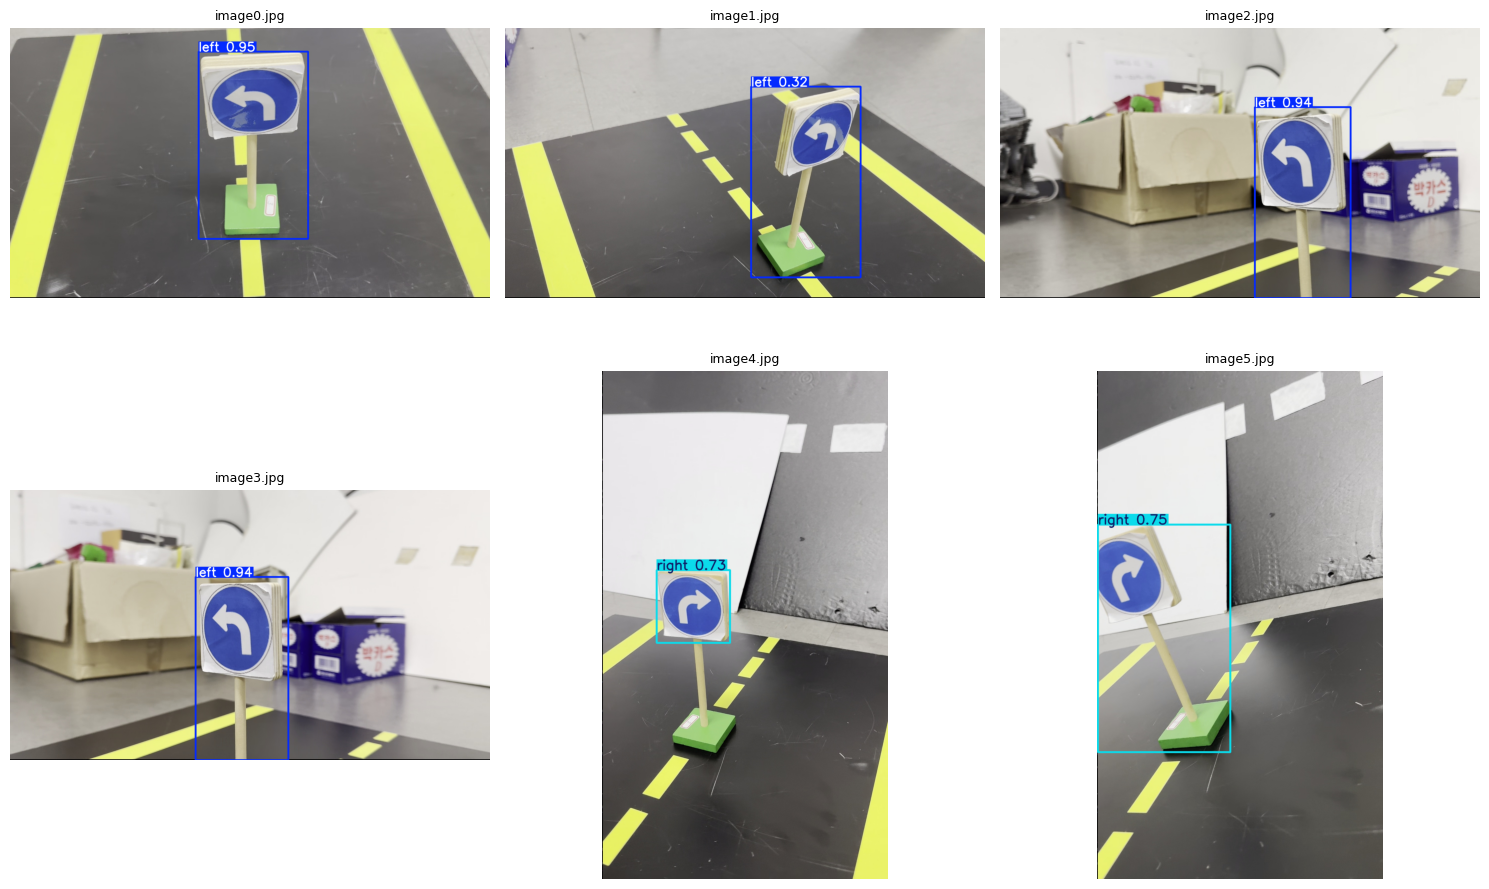

In [14]:
if YOLO is None:
    raise ImportError('ultralytics is not installed. Install it first.')

if 'best_model' not in globals():
    run_dir = resolve_run_dir(RUNS_ROOT, RUN_NAME)
    best_pt = run_dir / 'weights' / 'best.pt'
    print('resolved run_dir:', run_dir)
    print('best.pt         :', best_pt)
    best_model = YOLO(str(best_pt))

test_candidates = []
if test_img_dir.exists():
    test_candidates = sorted([
        path for path in test_img_dir.rglob('*')
        if path.is_file() and path.suffix.lower() in valid_exts
    ])
if not test_candidates and val_img_dir.exists():
    test_candidates = sorted([
        path for path in val_img_dir.rglob('*')
        if path.is_file() and path.suffix.lower() in valid_exts
    ])

if not test_candidates:
    print('No test/val images found.')
else:
    sample_tests = test_candidates[:min(6, len(test_candidates))]
    print('num_test_candidates:', len(test_candidates))
    test_results = best_model.predict([str(path) for path in sample_tests], conf=0.25, verbose=False)
    cols = 3
    rows = math.ceil(len(test_results) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax in axes:
        ax.axis('off')
    for ax, result in zip(axes, test_results):
        ax.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
        ax.set_title(Path(result.path).name, fontsize=9)
    plt.tight_layout()
    plt.show()


## 10) ONNX export


In [15]:
export_path = best_model.export(format='onnx', imgsz=IMGSZ)
print('exported:', export_path)


Ultralytics 8.4.48 🚀 Python-3.8.20 torch-2.4.1+cu121 CPU (13th Gen Intel Core i5-13400)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/home/jungjinwoo/Embe_learning/yolo_left_right/runs/left_right_sign_yolo11n-5/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/16.0 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━ 14.4/16.0 MB 74.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/226.2 MB ? eta -:--:--
   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/226.2 MB 78.6 MB/s eta 0:00:03
   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/226